In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt 

**Problem 1.** Suppose the data are `[1, 1.75, 2, 3, 3.25, 4]`.

- a. Sketch the empirical cumulative distribution function.
- b. Sketch the uniform kernel density estimator for a bandwidth of `h = 0.2`
- c. Compute the Silverman bandwidth for the uniform kernel using `h = 1.84 * SD * n**(-0.2)`.
- d. Sketch the uniform kernel density estimator for the Silverman bandwidth.
- e. How are b and d similar or different?

![My work for question 1](IMG_0482-1.jpeg)

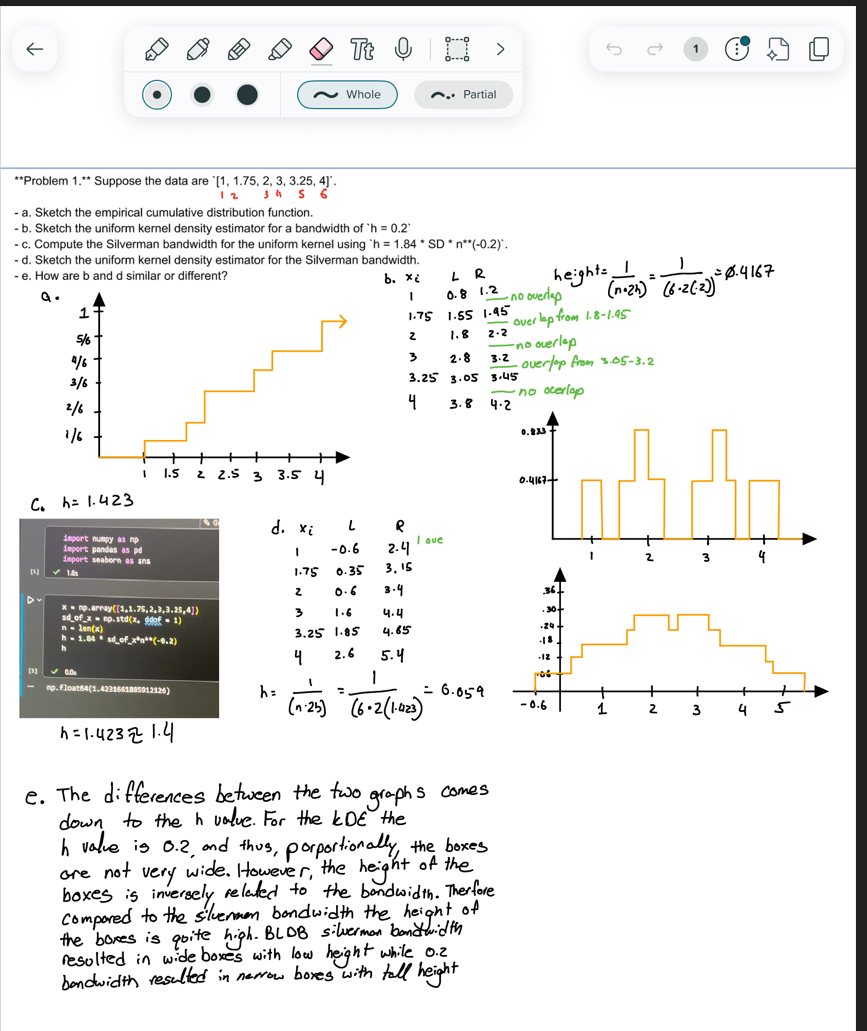

In [2]:
#problem 1
x = np.array([1,1.75,2,3,3.25,4])
sd_of_x = np.std(x, ddof = 1)
n = len(x)
h = 1.84 * sd_of_x*n**(-0.2)


**Problem 2.** Suppose the data `X = [-1, -0.5, 0, 0.5, 1]` were drawn from a standard Normal distribution.

- a. Using the uniform kernel with `h = 0.6`, compute the realized KDE at `x = 0`, `f_hat_h(0)`, directly from these five numbers.
- b. Now compute `E[f_hat_h(0)]` at the same `h = 0.6`.
- c. Calculate the true density at `x=0`, using the Normal distribution.
- d. Are b and c equal? What does this mean about bias? (Keep in mind, truly proving anything about bias would require us to compare `E[f_hat_h]` to the Normal distribution for all x; calculating this at one point is only an indication of what is going on that you can extrapolate from.)
- e. Recompute `E[f_hat_h(0)]` from (b) at a much smaller bandwidth, `h = 0.1`. What happens to the gap between `E[f_hat_h(0)]` and `f(0)` as `h` shrinks?
- f. Is `f_hat_h` a consistent estimator? Explain your reasoning.
- g. What are the main considerations in choosing a bandwidth value `h`?

In [3]:
X = np.array([-1,-0.5,0,0.5,1])
h = 0.6
n = len(X)
x_0 = np.atleast_1d(0)

#a
count = np.sum(np.abs(x_0[:,None]-X[None,:]) <= h, axis=1)
f_hat_h0 = count/(n*2*h)

#b
import math
E_f_hat_f0 = math.erf(h/math.sqrt(2)) / (2*h)
print(E_f_hat_f0)

#c
phi_0 = 1 / np.sqrt(2 * np.pi) * np.exp(-0**2 / 2)
print(phi_0)


0.37624480374987734
0.3989422804014327


#d
b and c are not equal. KDE is negatively bias'd. This is due to KDE estimating the height at a specific point by averaging over a window of +h and -h. Whereas, true denity finds the height at that exact point. 

In [4]:
h2= 0.1
E_f_hat_f02 = math.erf(h2/math.sqrt(2)) / (2*h2)
print(E_f_hat_f02)

0.39827837277028977


The gap between the KDE and the true density continues to shrink. This makes sense as the distance that KDE estimates from the true point shrinks. This would lead to a smaller bias.

#f
`f_hat_h` is not a consistent estimator if h stays constant. In this example, if h stays constant our `f_hat_h` will converge around 0.376 which is not the 0.399 value that we know f_hat to be from the true density calculation. We are able to get `f_hat_h` to be a consistent estimator if h shrinks or goes to zero. 

#g
We need to make sure that h is small enough to make our estimates with relatively low bias and we need to make sure that h is large enough to avoid loud noise/ large variance. 

**Problem 3.** Suppose the data are `X = [5, 7, 7, 8, 10]`, and fix the bandwidth at `h = 1.5` for both kernels below.

- a. Compute the uniform-kernel KDE, `f_hat_h(x)`, at `x = 6.0`, `x = 6.5`, `x = 7.0`, `x = 8.0`, and `x = 8.5`.
- b. Compute the Gaussian-kernel KDE at the same five values of `x`, using the same `h = 1.5`.
- c. Your part (a) values should jump abruptly between some of these five points, while your part (b) values should change smoothly. Identify where the biggest jump in (a) happens, and explain in terms of the two kernel *shapes* -- not just "one is smoother" -- why that jump exists in the uniform case but not the Gaussian case.
- d. Why might you prefer one kernel over the other in practice?

In [5]:
X = np.array([5,7,7,8,10])
h = 1.5

#a
def kde_calculation(x0,x,h):
    x_0 = np.atleast_1d(x0)
    n=len(x)
    count = np.sum(np.abs(x_0[:,None]-x[None,:]) <= h, axis=1)
    f_hat_h = count/(n*2*h)
    return f_hat_h

calculations = [6,6.5,7,8,8.5]
print(kde_calculation(calculations,X,h))

#b 
def gaussian_calculation(x0, x, h):
    x_0 = np.atleast_1d(x0)
    n = len(x)
    z = (x_0[:, None]-x[None,:]) / h
    kernel = (np.exp(-z**2 / 2) / np.sqrt(2 * np.pi))
    f_hat_h = np.sum(kernel, axis = 1) / (n * h)
    return f_hat_h

print(gaussian_calculation(calculations,X,h))
    

[0.2        0.26666667 0.2        0.2        0.26666667]
[0.15116668 0.16865731 0.17804448 0.16744524 0.15060231]


#c
The biggest jumps happen from x = 6.0 to 6.5 and from 8.0 to 8.5 (same jump between the two intervals of 0.2 to 0.2667), and then back down from 6.5 to 7.0. Each jumpp has a height of 0.067. The uniform kernel is shaped like a box - it counts every point within +/- h of x fully and gives zero weight to anything outside, so the box has a hard edge/jump/discontinuity. At x = 6.5, the points 5 and 8 sit exactly h away on the edge, so they get counted, and a point crossing the edge changes the count by a whole 1. Whereas the Gaussian kernel looks like a 'bell curve' or normal distribution centered on each point, where the weight fades gradually with distance and is continuous throughout. Therefore, as x moves, each point's contribution changes a little at a time, so we don't get the same discontinuities. BLUB Gaussian kernels have a bell curve distribution around the point, whereas uniform kernels are all or nothing +/- h away from the point

#d
I prefer a uniform kernel as it is simple to compute and interpret. Additionally, there doesn't seem to an edge in bias between the the two kernels - they are still both largely dependent on h for the bias in their answers. Also, given the simplicity of a uniform kernel as datasets scale the uniform kernel will be cheaper as it is only estimating points within h and not over the entire curve. However, a Gaussian kernel is differentiable and continuous throughout its curve as there are no jump discontinuities. 

**Problem 4.** Load `./data/heart_failure_clinical_records_dataset.csv`.

- a. Plot a
- kernel density estimate of `ejection_fraction`.
- b. Use Pandas' `df.sample(frac=1.0, replace=True)` to resample the data 15 times with replacement, plotting the kernel density estimtes for each sample.
- c. For what values of `ejection_fraction` is the original plot reliable? For which values is there noticeable variation in your plots of the resampled data?

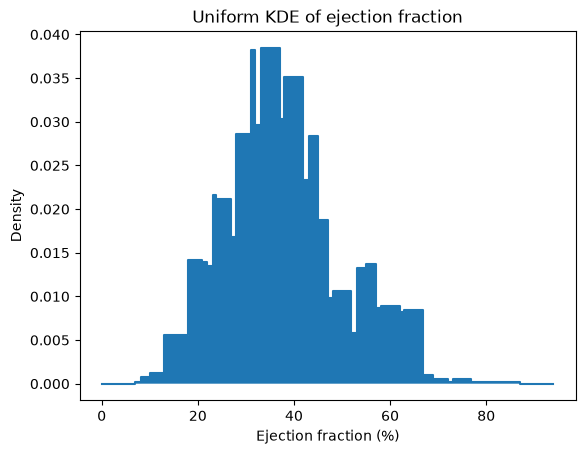

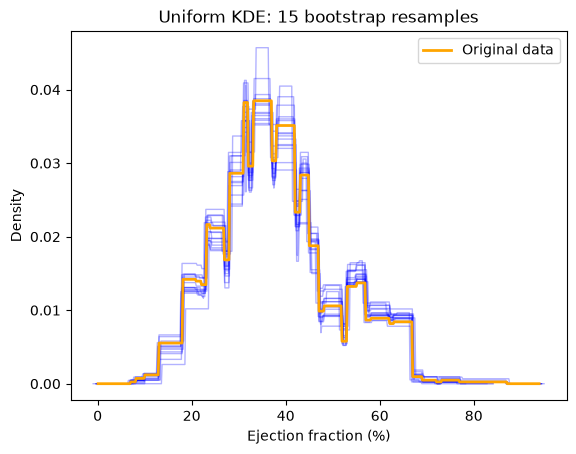

In [13]:
path = 'data/heart_failure_clinical_records_dataset.csv'
df = pd.read_csv(path)

def kde(X, K=500):
    n = len(X)
    X = np.array(X)
    h_u = 1.84 * X.std() * n ** (-0.2)  # Compute bandwidth
    x_grid = np.linspace(X.min() - 2*h_u, X.max() + 2*h_u, K)  # Grid to evaluate on
    I = np.abs(x_grid[:, None] - X[None, :]) < h_u  # Broadcast the indicator
    f_hat = np.sum(I, axis=1) / (2 * n * h_u)  # Compute kde
    return x_grid, f_hat

#a
x, f = kde(df['ejection_fraction'])
plt.step(x, f, where='mid')
plt.fill_between(x, f, step='mid')
plt.xlabel('Ejection fraction (%)')
plt.ylabel('Density')
plt.title('Uniform KDE of ejection fraction')
plt.show()

#b
fig, ax = plt.subplots()
for b in range(15):
    sample = df.sample(frac=1.0, replace=True, random_state=b)['ejection_fraction']
    x, f = kde(sample)
    ax.plot(x, f, color='blue', linewidth=1, alpha=0.3)

x0, f0 = kde(df['ejection_fraction'])
ax.plot(x0, f0, color='orange', linewidth=2, label='Original data')
ax.set(xlabel='Ejection fraction (%)', ylabel='Density',
       title='Uniform KDE: 15 bootstrap resamples')
ax.legend()
plt.show()
plt.show()


- The graph appears to be extremely reliable around 60-80% & 0-15% ejection fraction. There appears to be little variation in the samples. There does appear to be noticeable variation around the peak, 32-38%, and during a later spike, 45-55% ejection fraction. 